In [21]:
import numpy as np
from matplotlib import pyplot as plt
import nibabel as nb
from scipy.ndimage import gaussian_filter
from scipy.ndimage import distance_transform_edt
from glob import glob
import tifffile as tiff
import sys
import os
from glob import glob
sys.path.append('../')
from scipy import ndimage as ndi

# from slice_structure_identification_functions import compute_signed_distance_weight as compute_signed_distance_weight
# from slice_structure_identification_functions import compute_signed_distance_weight_filled as compute_signed_distance_weight_filled

import importlib

import slice_registration_functions
importlib.reload(slice_registration_functions)
from slice_registration_functions import apply_coordinate_mapping_2d, downsample_image, downsample_mask_to_counts, build_centroid_image

..............................................................................................................................................................................................................................................................................................................................................................................................................Processed 398 slices successfully.
Processed 398 slices successfully.


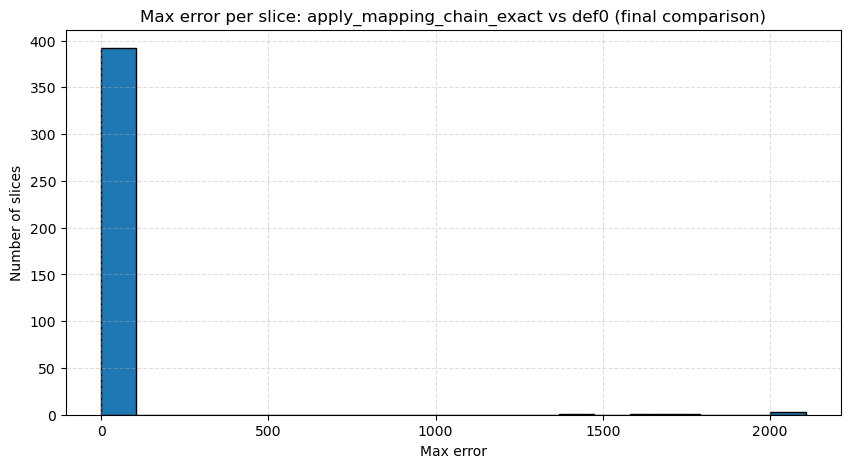

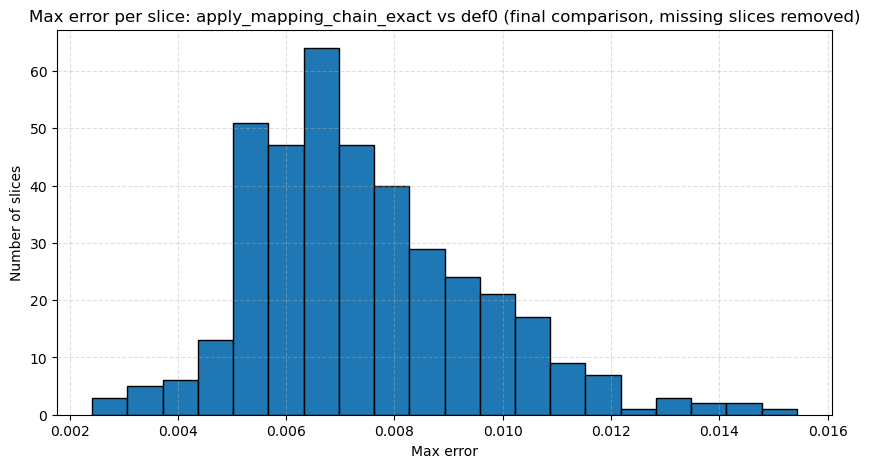

In [2]:
root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
# root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'

# Generate list of slice directories by globbing based on unique numeric prefix (zefir_XXXX_...)
# `glob` may be a function from previous imports, so call it directly.
orig_fnames = sorted(glob(os.path.join(root_dir, 'zefir_????_*_pix.nii.gz')))

max_errors = []
missing_slices = []
bad_slices = [] #exceed max_error_thresh
max_error_thresh = 5.0
for name_idx, orig_fname in enumerate(orig_fnames):
    print('.',end='')
    slice_name = os.path.basename(orig_fname)
    base_slice = slice_name.split('_downsample_10p002um_pix')[0]

    source_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix.nii.gz")
    mapping_img = os.path.join(root_dir, f"init_translation_slice_{base_slice.split('_')[1]}/{base_slice}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
    mapping_img3 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
    mapping_img4 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
    mapping_img5 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter4_ants-map.nii.gz")
    mapping_img6 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter5_ants-map.nii.gz")
    mapping_img7 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter6_ants-map.nii.gz")
    mapping_img8 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter7_ants-map.nii.gz")
    mapping_img9 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter8_ants-map.nii.gz")
    mapping_img10 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-map.nii.gz")
    
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-def0.nii.gz")

    if not (os.path.exists(source_img) and os.path.exists(mapping_img) and os.path.exists(mapping_img3) and os.path.exists(mapping_img4)):
        missing_slices.append(slice_name)
        continue
    # print(slice_name)
    src = nb.load(source_img)
    m1_ = nb.load(mapping_img)
    m2_ = nb.load(mapping_img3)
    m3_ = nb.load(mapping_img4)
    m4_ = nb.load(mapping_img5)
    m5_ = nb.load(mapping_img6)
    m6_ = nb.load(mapping_img7)
    m7_ = nb.load(mapping_img8)
    m8_ = nb.load(mapping_img9)
    m9_ = nb.load(mapping_img10)
    
    comparison = nb.load(final_comparison_img).get_fdata()
    # seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_).get_fdata()
    seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_).get_fdata()
    # comp_exact = apply_mapping_chain_exact(src, [m1_, m2_, m3_, m4_, m5_, m6_, m7_, m8_, m9_]).get_fdata()

    max_err = np.abs(seq -comparison).max()
    max_errors.append(max_err)
    if max_err > max_error_thresh:
        bad_slices.append((slice_name, max_err, name_idx))

max_errors = np.array(max_errors)
print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

plt.figure(figsize=(10, 5))
plt.hist(max_errors, bins=20, color='tab:blue', edgecolor='black')
plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison)')
plt.xlabel('Max error')
plt.ylabel('Number of slices')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(max_errors[max_errors<max_error_thresh], bins=20, color='tab:blue', edgecolor='black')
plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison, missing slices removed)')

plt.xlabel('Max error')
plt.ylabel('Number of slices')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()




In [3]:
#JUST DOWNSAMPLE TESTING

slice_pathroot_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
label_dir = '/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/'

input_res = 0.345
target_res = 400.0
rescale = target_res / input_res
rescale = int(round(rescale))

orig_cell_counts_fname = '/data/neuralabc/neuralabc_volunteers/macaque/testProject2/results_cell_counts/_Image_03_-_20x_cellCount_29_downsample_10p002um_pix.tif'
orig_cell_counts = tiff.imread(orig_cell_counts_fname)

labeled_mask = tiff.imread("/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0116__Image_03_-_20x_mask.ome.tif").astype(bool).astype(np.uint8) # read and convert to bin
src = nb.load("/tmp/zefir_sliceReg_optimized_v2_rescale_40/zefir_0116__Image_04_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz")

# centroid_seed_img = build_centroid_image(labeled_mask)

_ds_mtc = downsample_mask_to_counts(labeled_mask, rescale)
_ds_img = downsample_image(labeled_mask, rescale, pad_value=-1*0) #now counts per pixel

In [4]:
print(f"{'downsample factor':<40}: {rescale}")
print(f"{'downsample_image shape':<40}: {_ds_img.shape}")
print(f"{'downsample_image aspect ratio':<40}: {_ds_img.shape[0]/_ds_img.shape[1]}")
print(f"{'downsample_mask_to_counts shape':<40}: {_ds_mtc.shape}")
print(f"{'downsample_mask_to_counts aspect ratio':<40}: {_ds_mtc.shape[0]/_ds_mtc.shape[1]}")
print(f"{'src shape':<40}: {src.shape}")
print(f"{'src aspect ratio':<40}: {src.shape[0]/src.shape[1]}")
print(f"{'labeled_mask shape':<40}: {labeled_mask.shape}")
print(f"{'labeled_mask aspect ratio':<40}: {labeled_mask.shape[0]/labeled_mask.shape[1]}")
print(f"{'orig_cell_counts shape':<40}: {orig_cell_counts.shape}")
print(f"{'orig_cell_counts aspect ratio':<40}: {orig_cell_counts.shape[0]/orig_cell_counts.shape[1]}")


downsample factor                       : 1159
downsample_image shape                  : (77, 92)
downsample_image aspect ratio           : 0.8369565217391305
downsample_mask_to_counts shape         : (55, 66)
downsample_mask_to_counts aspect ratio  : 0.8333333333333334
src shape                               : (77, 103)
src aspect ratio                        : 0.7475728155339806
labeled_mask shape                      : (63158, 76025)
labeled_mask aspect ratio               : 0.8307530417625781
orig_cell_counts shape                  : (2178, 2622)
orig_cell_counts aspect ratio           : 0.8306636155606407


In [5]:
##LOG from test run with requested pixel size = 10, like the qupath export script

# downsample factor                       : 29
# downsample_image shape                  : (3050, 3671)
# downsample_image aspect ratio           : 0.8308362843911741
# downsample_mask_to_counts shape         : (2178, 2622)
# downsample_mask_to_counts aspect ratio  : 0.8306636155606407
# src shape                               : (77, 103)
# src aspect ratio                        : 0.7475728155339806
# labeled_mask shape                      : (63158, 76025)
# labeled_mask aspect ratio               : 0.8307530417625781
# orig_cell_counts shape                  : (2178, 2622)
# orig_cell_counts aspect ratio           : 0.8306636155606407

In [6]:
##LOG from test run with requested pixel size = 400, which should be the size of the pixels in the registration pipeline (10um downsampled by 40)

# downsample factor                       : 1159
# downsample_image shape                  : (77, 92)
# downsample_image aspect ratio           : 0.8369565217391305
# downsample_mask_to_counts shape         : (55, 66)
# downsample_mask_to_counts aspect ratio  : 0.8333333333333334
# src shape                               : (77, 103)
# src aspect ratio                        : 0.7475728155339806
# labeled_mask shape                      : (63158, 76025)
# labeled_mask aspect ratio               : 0.8307530417625781
# orig_cell_counts shape                  : (2178, 2622)
# orig_cell_counts aspect ratio           : 0.8306636155606407

In [7]:
slice_pathroot_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'

# root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'


label_dir = '/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/'


input_res = 0.345
target_res = 400.0
rescale = target_res / input_res
rescale = int(round(rescale))


# Generate list of slice directories by globbing based on unique numeric prefix (zefir_XXXX_...)
# `glob` may be a function from previous imports, so call it directly.
orig_fnames = sorted(glob(os.path.join(root_dir, 'zefir_????_*_pix.nii.gz')))

max_errors = []
missing_slices = []
bad_slices = [] #exceed max_error_thresh
max_error_thresh = 5.0
final_space_labels = {}
final_space_labels['img'] =[]
final_space_labels['fname_header'] =[]
final_space_labels['final_reg_space_def0'] = []
for name_idx, orig_fname in enumerate(orig_fnames):
    
    # labeled_maskos.path.basename(PC_files[0].split('_mask_')[0])
    # labeled_mask 

    slice_name = os.path.basename(orig_fname)
    base_slice = slice_name.split('_downsample_10p002um_pix')[0]
    fname_header = base_slice.split('__')[0]
    labeled_mask = glob(os.path.join(label_dir, f"{fname_header}_*_mask*.tif"))
    if len(labeled_mask) == 0:
        # print(f"No labeled mask found for {slice_name}")
        continue
    elif len(labeled_mask) > 1:
        # print(f"Multiple labeled masks found for {slice_name}: {labeled_mask}")
        continue        
    
        
    labeled_mask_fname = labeled_mask[0]
    if os.path.exists(labeled_mask_fname):
        print(f"Found labeled mask for {slice_name}: {labeled_mask_fname}")
    
    labeled_mask = tiff.imread(labeled_mask_fname).astype(bool).astype(np.uint8) # read and convert to bin
    
    # centroid_seed_img = build_centroid_image(labeled_mask)
    centroid_seed_img = labeled_mask #skipping centroids bc it takes too long for testing
    _ds_label_cnt = downsample_mask_to_counts(centroid_seed_img, rescale)

    # _ds_label_cnt = downsample_image(labeled_mask, rescale, pad_value=-1*0) #now counts per pixel
    
    



    source_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix.nii.gz")
    mapping_img = os.path.join(root_dir, f"init_translation_slice_{base_slice.split('_')[1]}/{base_slice}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
    mapping_img3 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
    mapping_img4 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
    mapping_img5 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter4_ants-map.nii.gz")
    mapping_img6 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter5_ants-map.nii.gz")
    mapping_img7 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter6_ants-map.nii.gz")
    mapping_img8 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter7_ants-map.nii.gz")
    mapping_img9 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter8_ants-map.nii.gz")
    mapping_img10 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-map.nii.gz")
    
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-def0.nii.gz")

    if not (os.path.exists(source_img) and os.path.exists(mapping_img) and os.path.exists(mapping_img3) and os.path.exists(mapping_img4)):
        missing_slices.append(slice_name)
        continue
    print(slice_name)
    src = nb.load(source_img)
    m1_ = nb.load(mapping_img)
    m2_ = nb.load(mapping_img3)
    m3_ = nb.load(mapping_img4)
    m4_ = nb.load(mapping_img5)
    m5_ = nb.load(mapping_img6)
    m6_ = nb.load(mapping_img7)
    m7_ = nb.load(mapping_img8)
    m8_ = nb.load(mapping_img9)
    m9_ = nb.load(mapping_img10)
    

    ## this breaks because the downsampled label count image is not the same shape as the source image
    # _d = np.zeros_like(src.get_fdata())
    # _d[...] = _ds_label_cnt
    # label_cnt_img = nb.Nifti1Image(_d, affine=src.affine, header=src.header)

    label_cnt_img = nb.Nifti1Image(_ds_label_cnt, affine=src.affine, header=src.header)



    if src.shape != label_cnt_img.shape:
        raise ValueError(f"Shape mismatch betweem source image and label count image: {src.shape} vs {label_cnt_img.shape}")

    # #create sham data full of 0s with one value in the middle of the image to track how it moves across the transformations
    # sham_data = np.zeros(src.shape, dtype=np.float32)
    # label_cnt_img = nb.Nifti1Image(_ds_label_cnt, affine=src.affine, header=src.header)

    comparison = nb.load(final_comparison_img).get_fdata()
    # seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_).get_fdata()
    labeled_seq = apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    apply_coordinate_mapping_2d(
                                        label_cnt_img, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_)

    seq = apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    apply_coordinate_mapping_2d(
                                        src, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_).get_fdata()

    final_space_labels['img'].append(labeled_seq)
    final_space_labels['fname_header'].append(fname_header)
    final_space_labels['final_reg_space_def0'].append(nb.load(final_comparison_img))
    break
    max_err = np.abs(seq -comparison).max()
    max_errors.append(max_err)
    if max_err > max_error_thresh:
        bad_slices.append((slice_name, max_err, name_idx))

max_errors = np.array(max_errors)
print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

# plt.figure(figsize=(10, 5))
# plt.hist(max_errors, bins=20, color='tab:blue', edgecolor='black')
# plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison)')
# plt.xlabel('Max error')
# plt.ylabel('Number of slices')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.show()

# plt.figure(figsize=(10, 5))
# plt.hist(max_errors[max_errors<max_error_thresh], bins=20, color='tab:blue', edgecolor='black')
# plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison, missing slices removed)')

# plt.xlabel('Max error')
# plt.ylabel('Number of slices')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.show()




Found labeled mask for zefir_0116__Image_04_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz: /data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0116__Image_03_-_20x_mask.ome.tif
zefir_0116__Image_04_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz


ValueError: Shape mismatch betweem source image and label count image: (77, 103) vs (55, 66)

In [25]:
print(nb.load(source_img).shape)
print(label_cnt_img.shape)
def downsample_mask_to_counts_v2(mask_like, factor, mode="qupath", prop_pad=0.2, pad_value=0):
    factor = max(1, int(round(factor)))

    arr = np.asarray(mask_like)
    h, w = arr.shape

    if mode == "floor":
        # Crop to divisible size (this trims when a remainder exists.)
        h2 = (h // factor) * factor
        w2 = (w // factor) * factor
        arr2 = arr[:h2, :w2]
    else:
        # Do padding the same way as downsample_image (same mode 'qupath' semantics in this utility):
        # 1) pad by proportion on each side
        # 2) apply extra pad to ensure rescale divisibility
        pad0 = int(np.ceil(h * prop_pad))
        pad1 = int(np.ceil(w * prop_pad))
        arr2 = np.pad(arr, ((pad0, pad0), (pad1, pad1)), mode='constant', constant_values=pad_value)

        padded_size0, padded_size1 = arr2.shape
        extra_pad_width = ((factor - padded_size0 % factor) % factor,
                           (factor - padded_size1 % factor) % factor)
        if extra_pad_width[0] > 0 or extra_pad_width[1] > 0:
            arr2 = np.pad(arr2,
                          ((0, extra_pad_width[0]), (0, extra_pad_width[1])),
                          mode='constant', constant_values=pad_value)

    h2, w2 = arr2.shape
    ds_counts = arr2.reshape(h2 // factor, factor, w2 // factor, factor).sum(axis=(1, 3))
    return ds_counts.astype(np.uint32)


(77, 103)
(55, 66)


In [23]:
_ds1 = downsample_image(centroid_seed_img, 10, pad_value=0)
print(_ds1.shape)

(8843, 10644)


In [35]:
_ds2 = downsample_mask_to_counts_v2(centroid_seed_img, rescale)
_ds2.shape


(77, 92)

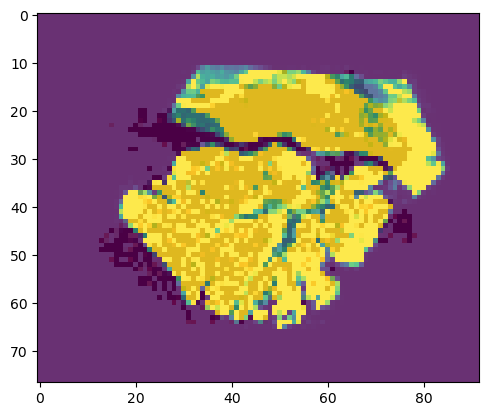

In [41]:
plt.imshow(nb.load(source_img).get_fdata(),vmax=500)
# plt.figure()
plt.imshow(_ds2,vmax=500,alpha=.2,cmap='Reds')
# print(np.sum(_ds1-_ds2))

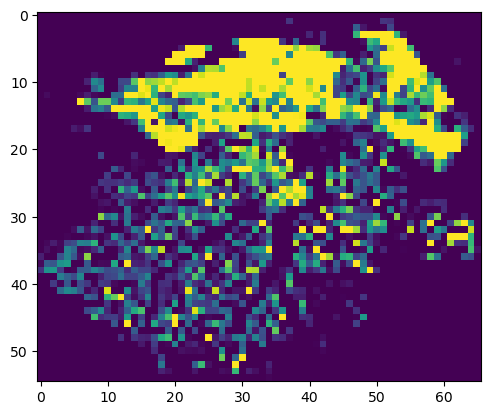

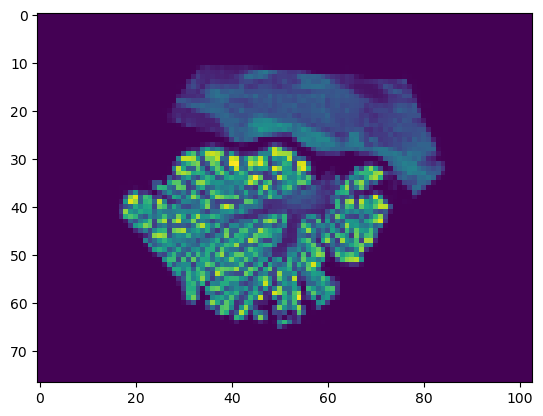

In [15]:
plt.imshow(_ds_res,vmax=5000)
plt.figure()
plt.imshow(nb.load(source_img).get_fdata())

In [189]:
_t = np.zeros_like(src.get_fdata())
_t[20,20] = 200
_t_img = nb.Nifti1Image(_t, affine=src.affine, header=src.header)
labeled_seq = apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    apply_coordinate_mapping_2d(
                                        _t_img, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_)


In [ ]:
_

(77, 103)

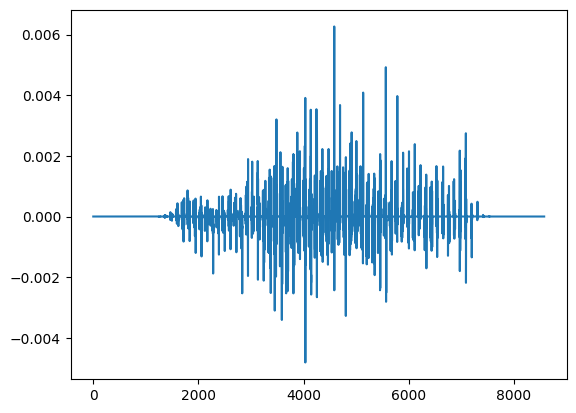

In [ ]:
#sanity check: is everything still good between the seq and the expected output

diff = final_space_labels['final_reg_space_def0'][0].get_fdata() - seq
plt.plot(diff.flatten())

In [5]:
labeled_mask = glob(os.path.join(label_dir, f"{fname_header}_*_mask*.tif"))
labeled_mask_fname = labeled_mask[0]
labeled_mask = tiff.imread(labeled_mask_fname)
labeled_mask = labeled_mask.astype(bool).astype(np.uint8) #convert to binary mask
_ds = downsample_image(labeled_mask, 40, pad_value=-1*0) #this sets the pad value to be a negative value outside of the range of the data, which is important for the SDF computation later, since we want to make sure that the padding does not create artificial boundaries that will impact the SDF computation (since it will create a boundary between the data and the padding)

orig_cell_counts_fname = '/data/neuralabc/neuralabc_volunteers/macaque/testProject2/results_cell_counts/_Image_03_-_20x_cellCount_29_downsample_10p002um_pix.tif'
orig_cell_counts = tiff.imread(orig_cell_counts_fname)



Exception in worker
Traceback (most recent call last):
  File "/home/remoteuser/johmat/.local/share/uv/python/cpython-3.11.14-linux-x86_64-gnu/lib/python3.11/concurrent/futures/thread.py", line 81, in _worker
    work_item = work_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "src/gevent/queue.py", line 406, in gevent._gevent_cqueue.SimpleQueue.get
  File "src/gevent/queue.py", line 422, in gevent._gevent_cqueue.SimpleQueue.get
  File "src/gevent/queue.py", line 398, in gevent._gevent_cqueue.SimpleQueue._SimpleQueue__get_or_peek
  File "src/gevent/_waiter.py", line 154, in gevent._gevent_c_waiter.Waiter.get
  File "src/gevent/_greenlet_primitives.py", line 65, in gevent._gevent_c_greenlet_primitives.SwitchOutGreenletWithLoop.switch
  File "src/gevent/_gevent_c_greenlet_primitives.pxd", line 35, in gevent._gevent_c_greenlet_primitives._greenlet_switch
gevent.exceptions.LoopExit: This operation would block forever
	Hub: <Hub '' at 0x7f83f690bb50 epoll pending=0 r

In [148]:
print(f"labeled_mask shape, data type: {labeled_mask.shape}, {labeled_mask.dtype}")
print(f"orig_cell_counts shape, data type: {orig_cell_counts.shape}, {orig_cell_counts.dtype}")
print()
print(f"label_cnt_img shape: {label_cnt_img.shape}")
print(f"label_cnt_img max: {label_cnt_img.get_fdata().max()}")
print(f"label_cnt_img type: {type(label_cnt_img)}")
print(f"label_cnt_img data type: {label_cnt_img.get_fdata().dtype}")
print()
print(f"seq shape: {seq.shape}")
print(f"seq max: {seq.max()}")
print(f"seq type: {type(seq)}")
print(f"seq data type: {seq.dtype}")

print()
print(f"labeled_seq shape: {labeled_seq.shape}")
print(f"labeled_seq max: {labeled_seq.get_fdata().max()}")
print(f"labeled_seq min: {labeled_seq.get_fdata().min()}")
print(f"labeled_seq unique values: {np.unique(labeled_seq.get_fdata())}")
print(f"labeled_seq type: {type(labeled_seq)}")
print(f"labeled_seq data type: {labeled_seq.get_fdata().dtype}")



# plt.imshow(label_cnt_img.get_fdata(), cmap='gray', vmax=1)
# plt.show()

# plt.imshow(labeled_seq.get_fdata(), cmap='gray', vmax=1)
# plt.show()

labeled_mask shape, data type: (63158, 76025), uint8
orig_cell_counts shape, data type: (2178, 2622), float32

label_cnt_img shape: (109, 132)
label_cnt_img max: 16.0
label_cnt_img type: <class 'nibabel.nifti1.Nifti1Image'>
label_cnt_img data type: float64

seq shape: (78, 110)
seq max: 1884.4905475617763
seq type: <class 'numpy.ndarray'>
seq data type: float64

labeled_seq shape: (78, 110)
labeled_seq max: 10.594052159062107
labeled_seq min: 0.0
labeled_seq unique values: [0.00000000e+00 1.52096619e-24 3.20922870e-24 ... 1.03495779e+01
 1.03844654e+01 1.05940522e+01]
labeled_seq type: <class 'nibabel.nifti1.Nifti1Image'>
labeled_seq data type: float64


In [159]:
rescale

580

In [ ]:
_ds1 = downsample_image(labeled_mask, 29, pad_value=-1*0) #this sets the pad value to be a negative value outside of the range of the data, which is important for the SDF computation later, since we want to make sure that the padding does not create artificial boundaries that will impact the SDF computation (since it will create a boundary between the data and the padding)
_ds2 = downsample_image(_ds1, 40, pad_value=-1*0) #this sets the pad value to be a negative value outside of the range of the data, which is important for the SDF computation later, since we want to make sure that the padding does not create artificial boundaries that will impact the SDF computation (since it will create a boundary between the data and the padding)






In [ ]:

input_res = 0.345
target_res = 10.0
rescale = target_res / input_res
rescale = int(round(rescale))

_ds3 = downsample_image(labeled_mask, rescale, pad_value=-1*0)

_ds3_simple = downsample_mask_to_counts(labeled_mask, rescale)

print(f"using version in this notebook: {_ds3_simple.shape} \nusing version in notebook (which has padding pre-ds): {_ds3.shape}")

using version in this notebook: (2177, 2621) 
 using version in notebook: (3050, 3671)


In [7]:
target_shape = orig_cell_counts.shape
current_shape = labeled_mask.shape
scale_factors = 1/(np.array(target_shape) / np.array(current_shape))

print(f"Target shape: {target_shape}")
print(f"Current shape: {current_shape}")
print(f"Scale factors: {scale_factors}")


Target shape: (2178, 2622)
Current shape: (63158, 76025)
Scale factors: [28.99816345 28.99504195]


In [47]:
input_res = 0.345
target_res = 10.0
rescale = target_res / input_res
rescale = int(round(rescale))


##THIS IS CORRECT BUT SLOW FOR TESTING (it turns cells into centroids before downsampling, which means that a singel cell doesnt get counted hundreds of times)
# centroid_seed_img = build_centroid_image(labeled_mask)
# ds_img = downsample_mask_to_counts(centroid_seed_img, rescale)
# ds_img_QP = downsample_mask_to_counts(centroid_seed_img, rescale, mode="qupath")

#THIS IS WRONG BUT FASTER FOR TESTING
ds_img = downsample_mask_to_counts(labeled_mask, rescale, mode="floor")
ds_img_QP = downsample_mask_to_counts(labeled_mask, rescale, mode="qupath")

print(f"factor={rescale}")
print(f"input shape = {labeled_mask.shape}")
print(f"floor downsampled shape = {ds_img.shape}")
print(f"qupath-like downsampled shape = {ds_img_QP.shape}")

factor=29
input shape = (63158, 76025)
floor downsampled shape = (2177, 2621)
qupath-like downsampled shape = (2178, 2622)
